In [1160]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint, uniform

from sklearn.preprocessing import LabelEncoder, OneHotEncoder

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import make_column_selector

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, learning_curve
from sklearn.metrics import recall_score, f1_score, balanced_accuracy_score

import pickle

In [1161]:
project_accidents_df = pd.read_csv('../data/agg_df.csv')
project_accidents_df.shape

(204145, 25)

In [1162]:
project_accidents_df = project_accidents_df[project_accidents_df["region"]=="Île-de-France"]
project_accidents_df.shape

(65093, 25)

In [1163]:
project_accidents_df = project_accidents_df.sample(20000, random_state=42)

In [1164]:
pd.set_option('display.max_columns', None)
project_accidents_df.head()

,accident_number,date,day_of_week,hour,road_category,road_layout,num_lanes,reserved_lane,road_profile,road_shape,surface_condition,infrastructure,road_location,speed_limit,injury_severity,users_involved,light_conditions,department,urban_area,intersection_type,weather,collision_type,latitude,longitude,region
130625,202100032450,2021-06-24,Thursday,15,Local & Access Roads,One Way,1,No value,Flat,Straight,Normal,No value,Road,30,1,2,Day,95,Inside urban area,No junction,Normal,Multi-car collision,49.049450,2.032880,Île-de-France
70563,202000016243,2020-10-19,Monday,8,Local & Access Roads,Two Way,2,No value,Flat,Straight,Normal,No value,Road,30,1,2,Day,94,Inside urban area,No junction,Normal,Multi-car collision,48.841776,2.519453,Île-de-France
111808,202100012477,2021-10-18,Monday,20,Local & Access Roads,Two Way,2,Cycle Lane,Flat,Curved,Wet / Slippery,No value,Cyclist / Pedestrian,30,1,2,Night,75,Inside urban area,Simple junction,Rain,2-car collision,48.895271,2.371927,Île-de-France
199973,202300050339,2023-08-25,Friday,18,Secondary Roads,One Way,2,Reserved Lane,Flat,Straight,Normal,Other,Reserved Lanes,50,1,4,Day,94,Inside urban area,No junction,Normal,2-car collision,48.776780,2.441350,Île-de-France
133238,202100035188,2021-06-11,Friday,17,Major Roads,One Way,3,No value,Flat,Straight,Normal,No value,Road,110,1,5,Day,91,Outside urban area,No junction,Normal,Multi-car collision,48.698130,2.314190,Île-de-France


In [1165]:
project_accidents_df.columns

Index(['accident_number', 'date', 'day_of_week', 'hour', 'road_category',
       'road_layout', 'num_lanes', 'reserved_lane', 'road_profile',
       'road_shape', 'surface_condition', 'infrastructure', 'road_location',
       'speed_limit', 'injury_severity', 'users_involved', 'light_conditions',
       'department', 'urban_area', 'intersection_type', 'weather',
       'collision_type', 'latitude', 'longitude', 'region'],
      dtype='object')

## Feature engineering

### `is_weekend`

In [1166]:
weekend_mapping = {
    'Monday': 0,
    'Tuesday': 0,
    'Wednesday': 0,
    'Thursday': 0,
    'Friday': 0,
    'Saturday': 1,
    'Sunday': 1
}

project_accidents_df['is_weekend'] = project_accidents_df['day_of_week'].map(weekend_mapping)

In [1167]:
project_accidents_df['is_weekend'].value_counts()

is_weekend
0    15423
1     4577
Name: count, dtype: int64

### `is_rush_hour`

In [1168]:
rush_hours = {6, 7, 8, 9, 16, 17, 18, 19}

project_accidents_df['is_rush_hour'] = (
    (project_accidents_df['is_weekend'] == 0) &
    (project_accidents_df['hour'].isin(rush_hours))
).astype(int)

In [1169]:
project_accidents_df['is_rush_hour'].value_counts()

is_rush_hour
0    12345
1     7655
Name: count, dtype: int64

### `hour_group`

In [1170]:
def hour_to_group(hour):
    if 0 <= hour <= 5:
        return "night"
    elif 6 <= hour <= 11:
        return "morning"
    elif 12 <= hour <= 17:
        return "afternoon"
    else:
        return "evening"

project_accidents_df["hour_group"] = project_accidents_df["hour"].apply(hour_to_group)

In [1171]:
project_accidents_df['hour_group'].value_counts()

hour_group
afternoon    7128
evening      5885
morning      5378
night        1609
Name: count, dtype: int64

### `month`

In [1172]:
project_accidents_df['date'] = pd.to_datetime(project_accidents_df['date'])
project_accidents_df['month'] = project_accidents_df['date'].dt.month

In [1173]:
project_accidents_df['month'].value_counts()

month
6     2040
10    2031
9     1983
7     1809
11    1695
12    1686
1     1650
5     1642
3     1472
2     1427
4     1291
8     1274
Name: count, dtype: int64

### `season`

In [1174]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

project_accidents_df['season'] = project_accidents_df['month'].apply(get_season)


In [1175]:
project_accidents_df['season'].value_counts()

season
Autumn    5709
Summer    5123
Winter    4763
Spring    4405
Name: count, dtype: int64

---

In [1176]:
project_accidents_df.head()

,accident_number,date,day_of_week,hour,road_category,road_layout,num_lanes,reserved_lane,road_profile,road_shape,surface_condition,infrastructure,road_location,speed_limit,injury_severity,users_involved,light_conditions,department,urban_area,intersection_type,weather,collision_type,latitude,longitude,region,is_weekend,is_rush_hour,hour_group,month,season
130625,202100032450,2021-06-24,Thursday,15,Local & Access Roads,One Way,1,No value,Flat,Straight,Normal,No value,Road,30,1,2,Day,95,Inside urban area,No junction,Normal,Multi-car collision,49.049450,2.032880,Île-de-France,0,0,afternoon,6,Summer
70563,202000016243,2020-10-19,Monday,8,Local & Access Roads,Two Way,2,No value,Flat,Straight,Normal,No value,Road,30,1,2,Day,94,Inside urban area,No junction,Normal,Multi-car collision,48.841776,2.519453,Île-de-France,0,1,morning,10,Autumn
111808,202100012477,2021-10-18,Monday,20,Local & Access Roads,Two Way,2,Cycle Lane,Flat,Curved,Wet / Slippery,No value,Cyclist / Pedestrian,30,1,2,Night,75,Inside urban area,Simple junction,Rain,2-car collision,48.895271,2.371927,Île-de-France,0,0,evening,10,Autumn
199973,202300050339,2023-08-25,Friday,18,Secondary Roads,One Way,2,Reserved Lane,Flat,Straight,Normal,Other,Reserved Lanes,50,1,4,Day,94,Inside urban area,No junction,Normal,2-car collision,48.776780,2.441350,Île-de-France,0,1,evening,8,Summer
133238,202100035188,2021-06-11,Friday,17,Major Roads,One Way,3,No value,Flat,Straight,Normal,No value,Road,110,1,5,Day,91,Outside urban area,No junction,Normal,Multi-car collision,48.698130,2.314190,Île-de-France,0,1,afternoon,6,Summer


In [1177]:
X = project_accidents_df.drop(columns=[
                                        'injury_severity',
                                        'accident_number',
                                        'date',
                                        'day_of_week',
                                        'hour',
                                        'road_layout',
                                        'reserved_lane',
                                        'road_profile',
                                        'road_shape',
                                        'infrastructure',
                                        'users_involved',
                                        'light_conditions',
                                        'intersection_type',
                                        #'latitude',
                                        #'longitude',
                                        'month',
                                        'region',
                                        'surface_condition',
                                        'collision_type'
                                        ])
y = project_accidents_df['injury_severity']

le = LabelEncoder()
y = le.fit_transform(y)

In [1178]:
X.head()

,road_category,num_lanes,road_location,speed_limit,department,urban_area,weather,latitude,longitude,is_weekend,is_rush_hour,hour_group,season
130625,Local & Access Roads,1,Road,30,95,Inside urban area,Normal,49.049450,2.032880,0,0,afternoon,Summer
70563,Local & Access Roads,2,Road,30,94,Inside urban area,Normal,48.841776,2.519453,0,1,morning,Autumn
111808,Local & Access Roads,2,Cyclist / Pedestrian,30,75,Inside urban area,Rain,48.895271,2.371927,0,0,evening,Autumn
199973,Secondary Roads,2,Reserved Lanes,50,94,Inside urban area,Normal,48.776780,2.441350,0,1,evening,Summer
133238,Major Roads,3,Road,110,91,Outside urban area,Normal,48.698130,2.314190,0,1,afternoon,Summer


In [1179]:
np.unique(y, return_counts=True)

(array([0, 1, 2]), array([17892,  1866,   242]))

In [1180]:
project_accidents_df.injury_severity.value_counts(normalize=True)

injury_severity
1    0.8946
2    0.0933
3    0.0121
Name: proportion, dtype: float64

In [1181]:
X.shape, y.shape

((20000, 13), (20000,))

In [1182]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [1183]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((16000, 13), (4000, 13), (16000,), (4000,))

In [1184]:
# # 💡 I will skip Oversampling step as bosting algorithms can handle imbalanced data well.
# smote = SMOTE(random_state=42)
# X_train, y_train = smote.fit_resample(X_train, y_train)
# X_train.shape, y_train.shape

### Encoding

In [1185]:
num_col = make_column_selector(dtype_include=['int64', 'float64'])
cat_col = make_column_selector(dtype_include=['object'])

# Skipping Scaling for numerical features
num_transformer = "passthrough"

cat_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer([
    ('num_transformer', num_transformer, num_col),
    ('cat_transformer', cat_transformer, cat_col)
])

preprocessor


ColumnTransformer(transformers=[('num_transformer', 'passthrough',
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x337faa720>),
                                ('cat_transformer',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x337fab590>)])

---

## Baseline

In [1186]:
baseline = (1 + 0 + 0) / 3
baseline

0.3333333333333333

📝 Baseline score is **0.33**

## Modeling

### Default LightGBM

In [1187]:
# LightGBM Pipeline
pipeline_lgb = Pipeline([
    ('preprocess', preprocessor),
    ('lgb', LGBMClassifier(random_state=42))
])

cv_results_lgb = cross_val_score(pipeline_lgb, X_train, y_train, cv=10, scoring='f1_macro').mean()
cv_results_lgb

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000703 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 597
[LightGBM] [Info] Number of data points in the train set: 14400, number of used features: 32
[LightGBM] [Info] Start training from score -0.111475
[LightGBM] [Info] Start training from score -2.371578
[LightGBM] [Info] Start training from score -4.410198
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000728 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 597
[LightGBM] [Info] Number of data points in the train set: 14400, number of used features: 32
[LightGBM] [Info] Start training from score -0.111475
[LightGBM] [Info] Start training from score -2.371578
[LightGBM] [Info] Start tr

0.34766406194130367

### Optimize LightGBM

In [1188]:
params = {
    'lgb__n_estimators': randint(50, 300),
    'lgb__max_depth': randint(3, 20),
    'lgb__learning_rate': uniform(0.01, 0.3),
    'lgb__num_leaves': randint(10, 100),
    'lgb__min_child_samples': randint(5, 100),
    'lgb__subsample': uniform(0.6, 0.4),          # 0.6〜1.0
    'lgb__colsample_bytree': uniform(0.6, 0.4),   # 0.6〜1.0
    'lgb__reg_lambda': uniform(0.5, 2.0),         # L2
    'lgb__reg_alpha': uniform(0.5, 2.0)           # L1
}

search_lgb = RandomizedSearchCV(
    pipeline_lgb,
    params,
    n_iter=50,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

search_lgb.fit(X_train, y_train)
search_lgb.best_params_

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001851 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 587
[LightGBM] [Info] Number of data points in the train set: 12800, number of used features: 27
[LightGBM] [Info] Start training from score -0.111455
[LightGBM] [Info] Start training from score -2.372136
[LightGBM] [Info] Start training from score -4.407344
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002840 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 587
[LightGBM] [Info] Number of data points in the train set: 12800, number of used features: 27
[LightGBM] [Info] Start training from score -0.111455
[LightGBM] [Info] Start training from score -2.371299
[LightGBM] [Info] Start trai

{'lgb__colsample_bytree': 0.7858695251758445,
 'lgb__learning_rate': 0.204932104792829,
 'lgb__max_depth': 12,
 'lgb__min_child_samples': 73,
 'lgb__n_estimators': 149,
 'lgb__num_leaves': 43,
 'lgb__reg_alpha': 1.021787246683428,
 'lgb__reg_lambda': 0.5306090805807695,
 'lgb__subsample': 0.9733745232317932}

In [1189]:
best_pipeline_lgb = search_lgb.best_estimator_

cv_results_lgb = cross_val_score(best_pipeline_lgb, X_train, y_train, cv=10, scoring='f1_macro').mean()
cv_results_lgb

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000525 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 587
[LightGBM] [Info] Number of data points in the train set: 14400, number of used features: 27
[LightGBM] [Info] Start training from score -0.111475
[LightGBM] [Info] Start training from score -2.371578
[LightGBM] [Info] Start training from score -4.410198
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spli

0.36301729692209855

## Learning curve

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000424 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 577
[LightGBM] [Info] Number of data points in the train set: 1280, number of used features: 23
[LightGBM] [Info] Start training from score -0.140700
[LightGBM] [Info] Start training from score -2.124177
[LightGBM] [Info] Start training from score -4.446565
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000464 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enou

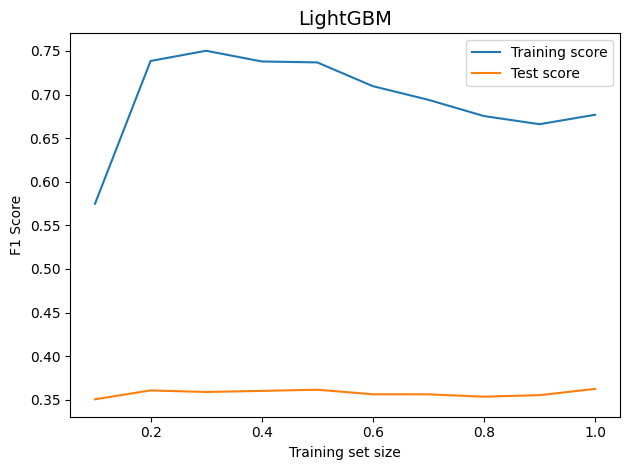

In [1190]:
train_sizes = np.linspace(0.1, 1.0, 10)

train_sizes_, train_scores, val_scores = learning_curve(
    estimator=best_pipeline_lgb,
    X=X_train,
    y=y_train,
    train_sizes=train_sizes,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

plt.plot(train_sizes, train_scores.mean(axis=1), label="Training score")
plt.plot(train_sizes, val_scores.mean(axis=1), label="Test score")

plt.title('LightGBM', fontsize=14)
plt.xlabel("Training set size")
plt.ylabel("F1 Score")
plt.legend()

plt.tight_layout()
plt.show()

## Final test

In [1191]:
# LightGBM
y_pred_lgb = best_pipeline_lgb.predict(X_test)
f1_lgb = f1_score(y_test, y_pred_lgb, average='macro')
print('LightGBM:  ', f1_lgb)

LightGBM:   0.3511301383668106


---

## Final model

In [1192]:
model = best_pipeline_lgb
model

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num_transformer',
                                                  'passthrough',
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x172ed5250>),
                                                 ('cat_transformer',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x15d8c45f0>)])),
                ('lgb',
                 LGBMClassifier(colsample_bytree=0.7858695251758445,
                                learning_rate=0.204932104792829, max_depth=12,
                                min_child_samples=73, n_estimators=149,
                                num_leaves=43, random_state=42,
                                reg_alpha=1.021787246683428,
                                reg_lambda=0.5306090805807695,
                                subsample=0.9733745232317932))])

In [1194]:
with open('../models/project_accidents_model_lgbm.pkl', 'wb') as f:
    pickle.dump(model, f)

In [ ]:
# with open('../models/project_accidents_model.pkl', 'rb') as f:
#     model = pickle.load(f)